In [ ]:
# ==============================
# FULL ML PIPELINE (ONE CELL)
# ==============================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ------------------------------
# LOAD DATA
# ------------------------------
df = pd.read_csv("ai.csv")

# ------------------------------
# DATA CLEANING
# ------------------------------

# Drop useless ID columns
df.drop(columns=["UDI", "Product ID"], inplace=True)

# Handle missing values (if any)
df.fillna(df.median(numeric_only=True), inplace=True)

# Encode categorical column
le = LabelEncoder()
df["Type"] = le.fit_transform(df["Type"])

# ------------------------------
# AVOID DATA LEAKAGE ⚠️
# ------------------------------
# Remove failure-type columns (they leak target info)
leakage_cols = ["TWF", "HDF", "PWF", "OSF", "RNF"]
df.drop(columns=leakage_cols, inplace=True)

# ------------------------------
# FEATURES & TARGET
# ------------------------------
X = df.drop(columns=["Machine failure"])
y = df["Machine failure"]

# Check class balance
print("Class Distribution:\n", y.value_counts(), "\n")

# ------------------------------
# TRAIN-TEST SPLIT
# ------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ------------------------------
# SCALING (CRITICAL for KNN & LR)
# ------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ------------------------------
# LOGISTIC REGRESSION
# ------------------------------
lr = LogisticRegression(class_weight='balanced', max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("===== LOGISTIC REGRESSION =====")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("Classification Report:\n", classification_report(y_test, y_pred_lr))

# ------------------------------
# KNN (TRY MULTIPLE K VALUES)
# ------------------------------
print("\n===== KNN RESULTS =====")

best_k = None
best_acc = 0

for k in [3, 5, 7, 9]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred_knn = knn.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred_knn)
    print(f"K={k} -> Accuracy: {acc}")

    if acc > best_acc:
        best_acc = acc
        best_k = k

# Train final KNN with best K
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_scaled, y_train)
y_pred_knn_final = knn_final.predict(X_test_scaled)

print(f"\nBest K: {best_k}")
print("Final KNN Accuracy:", best_acc)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn_final))
print("Classification Report:\n", classification_report(y_test, y_pred_knn_final))

Class Distribution:
 Machine failure
0    9661
1     339
Name: count, dtype: int64 

===== LOGISTIC REGRESSION =====
Accuracy: 0.8175
Confusion Matrix:
 [[1583  356]
 [   9   52]]
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.82      0.90      1939
           1       0.13      0.85      0.22        61

    accuracy                           0.82      2000
   macro avg       0.56      0.83      0.56      2000
weighted avg       0.97      0.82      0.88      2000


===== KNN RESULTS =====
K=3 -> Accuracy: 0.9765
K=5 -> Accuracy: 0.979
K=7 -> Accuracy: 0.979
K=9 -> Accuracy: 0.9775

Best K: 5
Final KNN Accuracy: 0.979
Confusion Matrix:
 [[1935    4]
 [  38   23]]
Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99      1939
           1       0.85      0.38      0.52        61

    accuracy                           0.98      2000
   macro avg       0.92  

In [ ]:
def predict_failure(data_dict):
    df = pd.DataFrame([data_dict])
    df["Type"] = le.transform(df["Type"])
    df_scaled = scaler.transform(df)

    pred = lr.predict(df_scaled)[0]
    return "Failure" if pred == 1 else "No Failure"

In [ ]:
# ==============================
# NEW MACHINE DATA (EXAMPLE)
# ==============================

# Order MUST match training features
new_data = pd.DataFrame([{
    "Type": "L",                 # L / M / H
    "Air temperature [K]": 298.5,
    "Process temperature [K]": 308.7,
    "Rotational speed [rpm]": 1500,
    "Torque [Nm]": 45,
    "Tool wear [min]": 10
}])

# ------------------------------
# APPLY SAME PREPROCESSING
# ------------------------------

# Encode Type using SAME encoder
new_data["Type"] = le.transform(new_data["Type"])

# Scale using SAME scaler
new_data_scaled = scaler.transform(new_data)

# ------------------------------
# PREDICTIONS
# ------------------------------

# Logistic Regression Prediction
lr_pred = lr.predict(new_data_scaled)[0]

# KNN Prediction
knn_pred = knn_final.predict(new_data_scaled)[0]

# ------------------------------
# OUTPUT
# ------------------------------
print("Logistic Regression Prediction:", "Failure" if lr_pred == 1 else "No Failure")
print("KNN Prediction:", "Failure" if knn_pred == 1 else "No Failure")

Logistic Regression Prediction: No Failure
KNN Prediction: No Failure


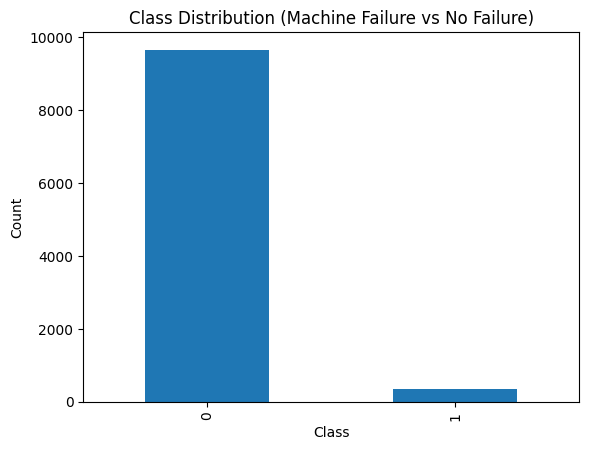

In [ ]:
import matplotlib.pyplot as plt

y.value_counts().plot(kind='bar')
plt.title("Class Distribution (Machine Failure vs No Failure)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

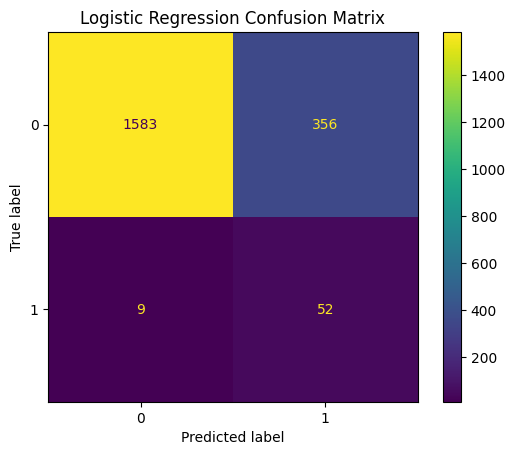

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

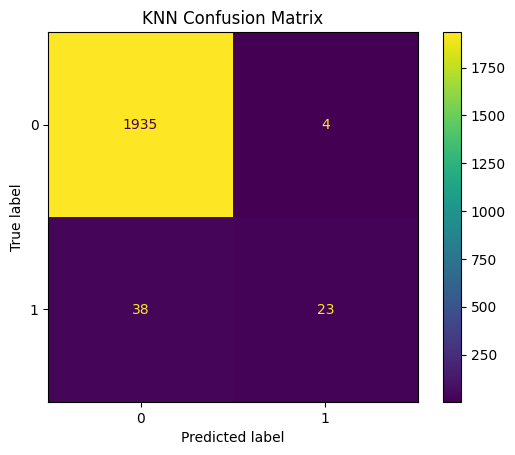

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn_final)
plt.title("KNN Confusion Matrix")
plt.show()

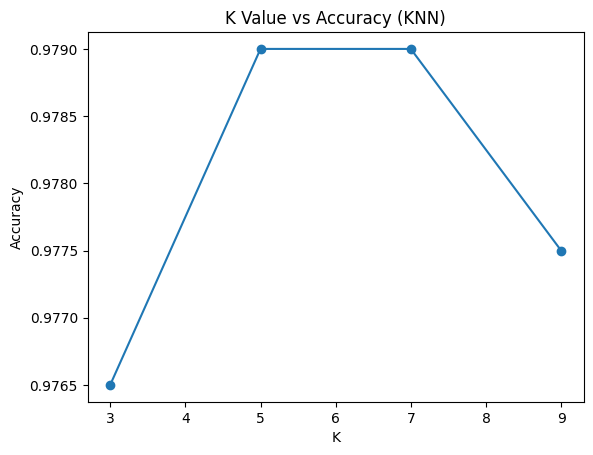

In [ ]:
k_values = [3, 5, 7, 9]
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    pred = knn.predict(X_test_scaled)
    accuracies.append(accuracy_score(y_test, pred))

plt.plot(k_values, accuracies, marker='o')
plt.title("K Value vs Accuracy (KNN)")
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.show()

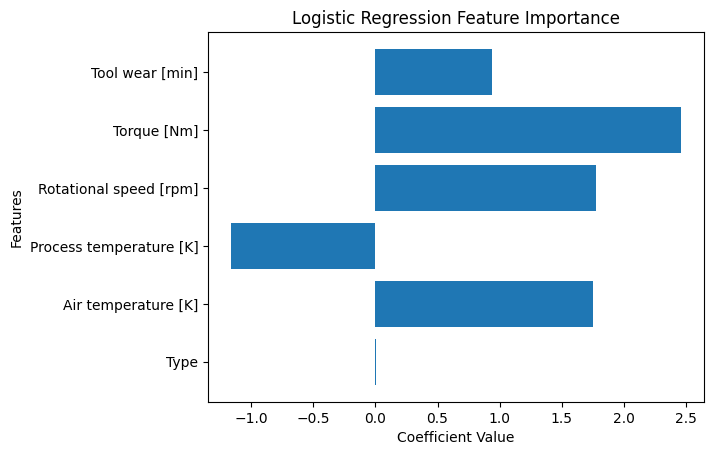

In [ ]:
features = X.columns
coefficients = lr.coef_[0]

plt.barh(features, coefficients)
plt.title("Logistic Regression Feature Importance")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.show()

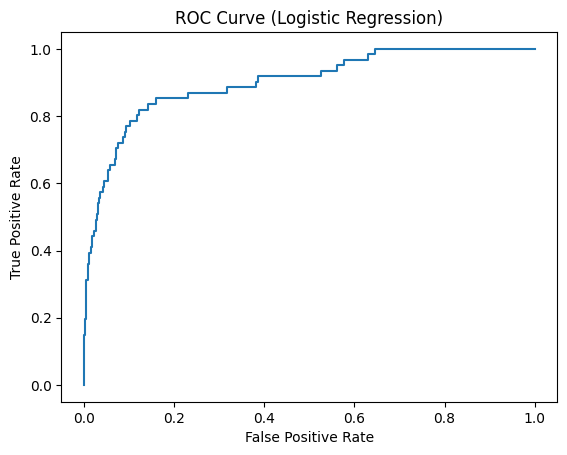

AUC Score: 0.9000160637137615


In [ ]:
from sklearn.metrics import roc_curve, auc

y_prob = lr.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.title("ROC Curve (Logistic Regression)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

print("AUC Score:", roc_auc)